In [ ]:
import pyreadr
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carga el archivo .rdata
result = pyreadr.read_r('../DATASETS/Hospital Triage and Patient History Data/5v_cleandf.rdata')


In [7]:
# Los archivos .rdata pueden contener varios objetos, 
# result.keys() te dirá el nombre del dataframe interno
print(result.keys())

# Supongamos que el objeto se llama 'df'
df = result['df'] 

# Ahora ya puedes verlo como un DataFrame normal de pandas
print(df.head())

odict_keys(['df'])
  dep_name esi age  gender           ethnicity  \
0        B   4  40    Male  Hispanic or Latino   
1        B   4  66    Male  Hispanic or Latino   
2        B   2  66    Male  Hispanic or Latino   
3        A   2  66    Male  Hispanic or Latino   
4        A   3  84  Female  Hispanic or Latino   

                                        race     lang     religion  \
0                         White or Caucasian  English         None   
1  Native Hawaiian or Other Pacific Islander  English  Pentecostal   
2  Native Hawaiian or Other Pacific Islander  English  Pentecostal   
3  Native Hawaiian or Other Pacific Islander  English  Pentecostal   
4                                      Other    Other  Pentecostal   

  maritalstatus  employstatus  ... cc_vaginaldischarge cc_vaginalpain  \
0        Single     Full Time  ...                   0              0   
1       Married  Not Employed  ...                   0              0   
2       Married  Not Employed  ...      

--- ANÁLISIS DEL DATASET ORIGINAL ---
Dimensiones iniciales: (560486, 972)


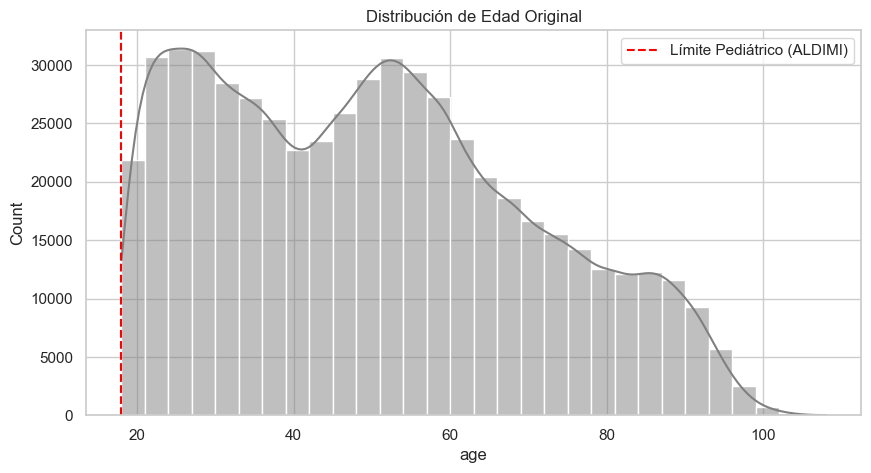

Total de valores nulos iniciales: 161875061


C:\Users\rivas\AppData\Local\Temp\ipykernel_15992\2362704836.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='esi', data=df, palette='magma')


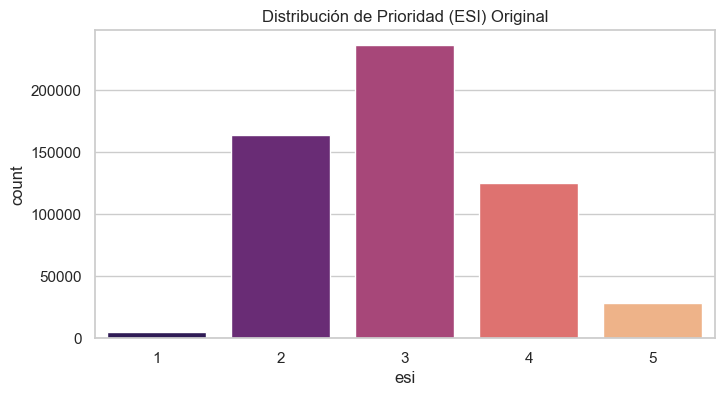

In [16]:
print("--- ANÁLISIS DEL DATASET ORIGINAL ---")
print(f"Dimensiones iniciales: {df.shape}")

# 1. Distribución de Edad Original (Para mostrar que hay demasiados adultos)
plt.figure(figsize=(10, 5))
sns.histplot(df['age'], bins=30, kde=True, color='gray')
plt.axvline(18, color='red', linestyle='--', label='Límite Pediátrico (ALDIMI)')
plt.title('Distribución de Edad Original')
plt.legend()
plt.show()

# 2. Análisis de Valores Nulos
nulls = df.isnull().sum().sum()
print(f"Total de valores nulos iniciales: {nulls}")

# 3. Distribución del Target (ESI) original
plt.figure(figsize=(8, 4))
sns.countplot(x='esi', data=df, palette='magma')
plt.title('Distribución de Prioridad (ESI) Original')
plt.show()

In [17]:

# 1. FILTRO PEDIÁTRICO (Core de ALDIMI)
# Solo pacientes menores o iguales a 18 años
df_aldimi = df[df['age'] <= 18].copy()

# 2. SELECCIÓN DE COLUMNAS ESTRATÉGICAS
# Definimos las categorías que realmente importan para el modelo de prioridad
cols_demograficas = ['esi', 'age', 'gender', 'arrivalmonth', 'arrivalday', 'arrivalhour_bin']

# Indicadores médicos directamente relacionados con Cáncer/Gravedad pediátrica
cols_clinicas = [
    '2ndarymalig', # Malignidad/Cáncer
    'anemia',      # Común en pacientes oncológicos
    'nauseavomit'
]

# Síntomas (Chief Complaints) relevantes para oncología y triage infantil
# Filtramos de las 972 columnas solo las que empiezan con 'cc_' y son útiles
sintomas_interes = [
    'cc_fever', 'cc_abdominalpain', 'cc_weakness', 'cc_fatigue', 
    'cc_nausea', 'cc_headache', 'cc_diarrhea', 'cc_dehydration',
    'cc_pain'
]

# 3. CONSOLIDACIÓN
# Unimos todas las columnas seleccionadas
columnas_finales = cols_demograficas + cols_clinicas + sintomas_interes
df_final = df_aldimi[columnas_finales].dropna(subset=['esi']) # Aseguramos que el target exista

print(f"Dataset original: {df.shape}")
print(f"Dataset ALDIMI (Pediátrico Filtrado): {df_final.shape}")

Dataset original: (560486, 972)
Dataset ALDIMI (Pediátrico Filtrado): (4860, 18)


--- ANÁLISIS DEL DATASET REFINADO (ALDIMI) ---
Dimensiones finales: (4860, 18)


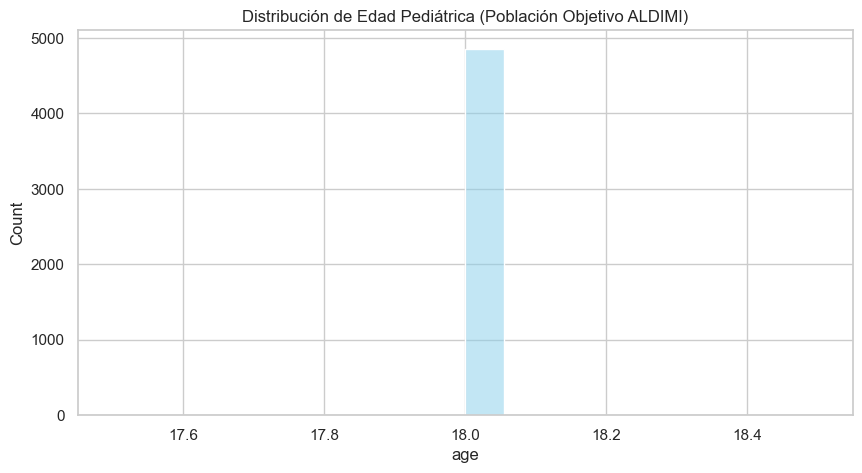

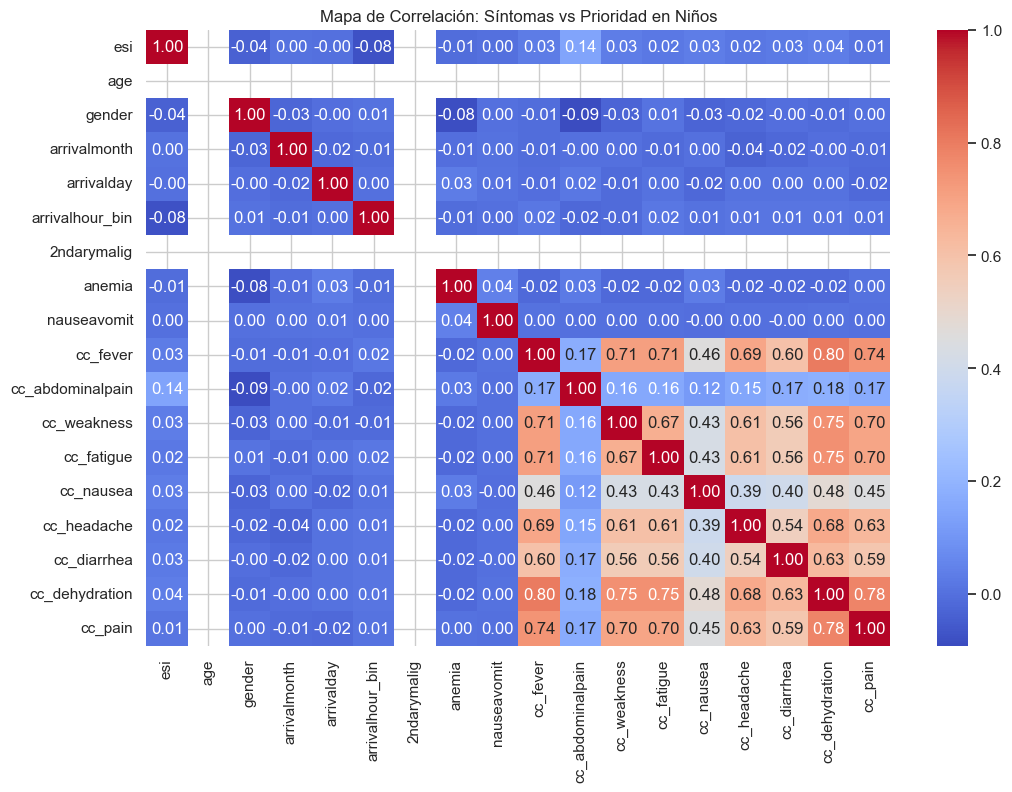

C:\Users\rivas\AppData\Local\Temp\ipykernel_15992\1479093146.py:21: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='esi', y='cc_fever', data=df_final, ci=None, palette='viridis')
C:\Users\rivas\AppData\Local\Temp\ipykernel_15992\1479093146.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='esi', y='cc_fever', data=df_final, ci=None, palette='viridis')


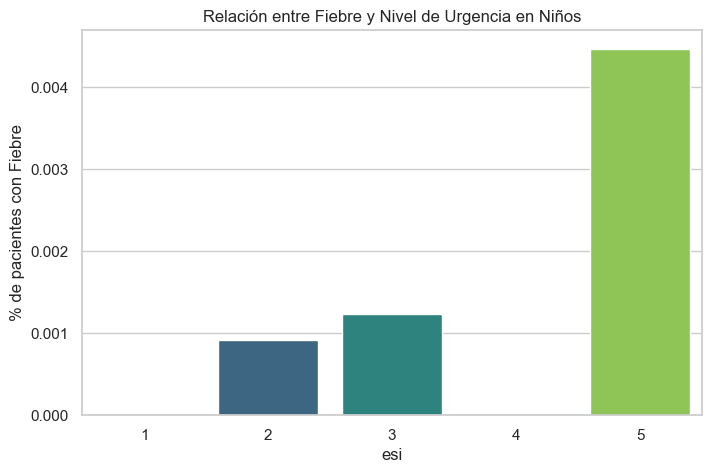

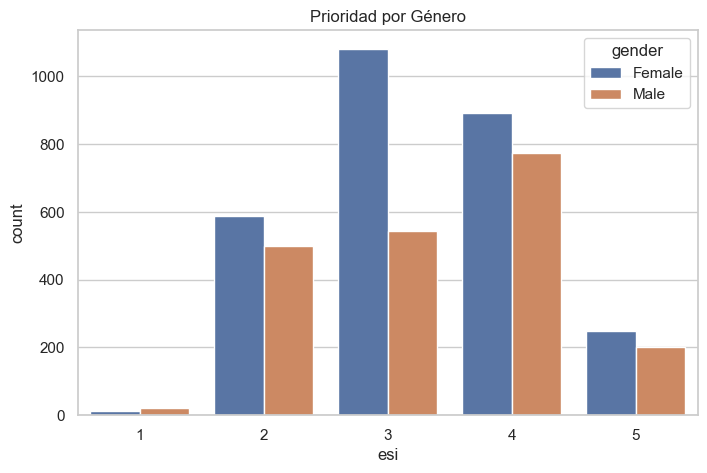

In [20]:
print("--- ANÁLISIS DEL DATASET REFINADO (ALDIMI) ---")
print(f"Dimensiones finales: {df_final.shape}")

# 1. Nueva Distribución de Edad
plt.figure(figsize=(10, 5))
sns.histplot(df_final['age'], bins=18, kde=True, color='skyblue')
plt.title('Distribución de Edad Pediátrica (Población Objetivo ALDIMI)')
plt.show()

# 2. Correlación de Síntomas vs Prioridad (Heatmap)
# Convertimos el target a numérico para correlación si es necesario
plt.figure(figsize=(12, 8))
corr = df_final.apply(lambda x: pd.factorize(x)[0]).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Correlación: Síntomas vs Prioridad en Niños')
plt.show()

# 3. Análisis Específico: Impacto de la Fiebre en la Prioridad
# (Crucial para oncología pediátrica)
plt.figure(figsize=(8, 5))
sns.barplot(x='esi', y='cc_fever', data=df_final, ci=None, palette='viridis')
plt.ylabel('% de pacientes con Fiebre')
plt.title('Relación entre Fiebre y Nivel de Urgencia en Niños')
plt.show()

# 4.Prioridad por genero
plt.figure(figsize=(8, 5))
sns.countplot(x='esi', hue='gender', data=df_final)
plt.title('Prioridad por Género')
plt.show()


In [26]:
# 4. EXPORTACIÓN PARA EL EQUIPO
df_final.to_csv('../DATASETS/Hospital Triage and Patient History Data/dataset_limpio.csv', index=False)